         Date          Open          High           Low         Close  \
0  2019-06-18   9128.269531   9149.763672   8988.606445   9062.045898   
1  2019-06-19   9068.174805   9277.677734   9051.094727   9271.459961   
2  2019-06-20   9271.567383   9573.689453   9209.416992   9519.200195   
3  2019-06-21   9526.833984  10130.935547   9526.833984  10127.998047   
4  2019-06-22  10151.890625  11171.013672  10083.189453  10719.981445   

     Volume Currency  
0  952850.0      USD  
1  131077.0      USD  
2   83052.0      USD  
3   76227.0      USD  
4   84485.0      USD  
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Currency    0
dtype: int64


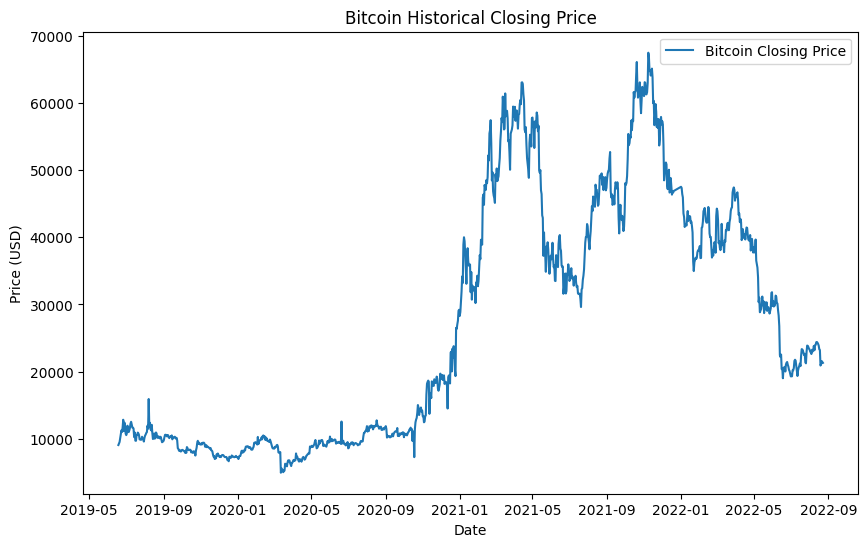

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Bitcoin BEP2.csv')  # Replace with the actual file name
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Plot the closing price
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df['Close'], label='Bitcoin Closing Price')
plt.title('Bitcoin Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Use only the 'Close' column
data = df['Close'].values.reshape(-1, 1)

# Normalize the data (scale between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences of 60 days to predict the next day
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Reshape X to be compatible with LSTM input (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build the LSTM model
model = Sequential()

# First LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Dense layer
model.add(Dense(units=25))
model.add(Dense(units=1))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
model.summary()

c:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.0895 - val_loss: 0.0068
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0063 - val_loss: 0.0023
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0048 - val_loss: 0.0025
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0048 - val_loss: 0.0020
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0041 - val_loss: 0.0019
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0041 - val_loss: 0.0023
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0031 - val_loss: 0.0021
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0036 - val_loss: 0.0020
Epoch 10/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0032 - val_loss: 0.0028
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0

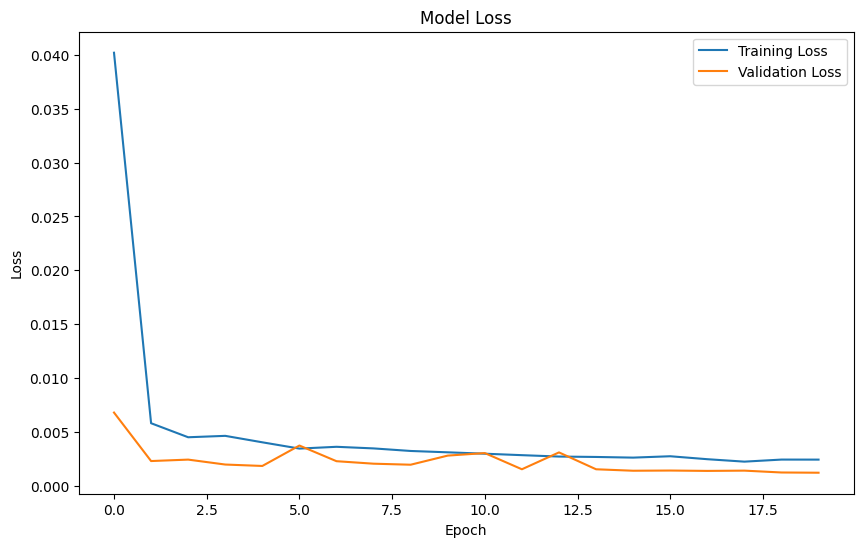

In [4]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure actual_prices and predictions are defined
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))  # Inverse transform actual test values
predictions = model.predict(X_test)  # Make predictions
predictions = scaler.inverse_transform(predictions)  # Inverse transform predictions

# Calculate MAE and RMSE
mae = mean_absolute_error(actual_prices, predictions)
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
Mean Absolute Error (MAE): 1585.5118971175802
Root Mean Squared Error (RMSE): 2203.5203281526415


In [12]:
model.save('bitcoin_price_predictor.h5')